# NextTick - Phase 3: Regression Models

## Overview

This notebook trains and compares three models for **next-day return prediction** - predicting the percentage change in a stock's close price tomorrow versus today. This is a regression task (predict a real number).

The three models:

1. **Linear Regression** - linear baseline, no hyperparameter tuning
2. **Random Forest Regressor** - tree ensemble with cross-validated hyperparameter search
3. **LSTM Regressor** - deep sequence model with stacked LSTM layers, fixed architecture

Each model uses the same data split, the same 21 features, and the same preprocessing as Phase 2. Only the target and loss functions change.

## Data split

Chronological **70/15/15** train/validation/test.

## Evaluation metrics

- **MAE** (Mean Absolute Error) - average magnitude of prediction error, in units of daily return (so 0.01 = 1 percentage point off on average)
- **RMSE** (Root Mean Squared Error) - like MAE but penalizes large errors more heavily
- **R-squared** - fraction of variance explained by the model. 0 means "as good as predicting the mean", negative means "worse than predicting the mean"

## Outputs

- `models/linear_regression.pkl`
- `models/random_forest_regressor.pkl`
- `models/lstm_regressor.pt`
- `models/scaler.pkl` (the StandardScaler used to preprocess features)

## 1. Imports and Setup

Same setup as Phase 2: PyTorch for the LSTM, scikit-learn for Linear Regression and Random Forest.

In [1]:
# Standard data stack
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import time
from pathlib import Path

# scikit-learn: regressors, CV, scaling, metrics
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# PyTorch for the LSTM
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Reproducibility - seed everything that could introduce randomness
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

# Device setup - use GPU if available, otherwise fall back to CPU
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch: {torch.__version__}")
print(f"Device:  {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU:     {torch.cuda.get_device_name(0)}")

PyTorch: 2.11.0+cu128
Device:  cuda
GPU:     NVIDIA GeForce RTX 4060 Laptop GPU


## 2. Load Dataset and Define Features

We load the 50-ticker dataset produced by Phase 1. The 21 features are already computed; we just need to specify which columns are features and which are targets.

In [2]:
# Load the dataset saved by Phase 1
df_full = pd.read_csv(
    "../data/processed/nexttick_dataset_50tickers.csv",
    index_col="Date",
    parse_dates=True,
).sort_index()

# 21 features 
FEATURE_COLS = [
    # Price / technical (6)
    "daily_return", "sma_10", "sma_20", "volatility_10", "momentum_10", "rsi_14",
    # Market / macro (10)
    "spy_return", "vix_level", "sector_return", "relative_to_spy", "relative_to_sector",
    "tnx_change", "dxy_change", "oil_return", "day_of_week", "month",
    # OHLCV-derived (5)
    "overnight_gap", "intraday_return", "daily_range_pct", "close_location", "relative_volume",
]
assert len(FEATURE_COLS) == 21

TARGET_COL = "target_return"  # Continuous target: next-day pct change in close

print(f"Dataset: {df_full.shape}")
print(f"Tickers: {df_full['ticker'].nunique()}")
print(f"Date range: {df_full.index.min().date()} -> {df_full.index.max().date()}")
print(f"Features: {len(FEATURE_COLS)}")
print(f"Target:   {TARGET_COL}")

# target distribution
print(f"\nTarget statistics:")
print(f"  Mean:     {df_full[TARGET_COL].mean():+.5f}")
print(f"  Std:      {df_full[TARGET_COL].std():.5f}")
print(f"  Min:      {df_full[TARGET_COL].min():+.5f}")
print(f"  Max:      {df_full[TARGET_COL].max():+.5f}")
print(f"  |mean|:   {df_full[TARGET_COL].abs().mean():.5f}  (typical daily move)")

Dataset: (61750, 29)
Tickers: 50
Date range: 2021-05-18 -> 2026-04-17
Features: 21
Target:   target_return

Target statistics:
  Mean:     +0.00058
  Std:      0.01898
  Min:      -0.35117
  Max:      +0.35949
  |mean|:   0.01284  (typical daily move)


## 3. Chronological 70/15/15 Train/Val/Test Split

Chronological split because we're predicting the future from the past - random shuffling would leak future data into training.

In [3]:
# Get all unique dates in sorted order, then pick cutoff dates at 70% and 85% positions
unique_dates = df_full.index.unique().sort_values()
n_dates = len(unique_dates)
train_cutoff = unique_dates[int(n_dates * 0.70)]
val_cutoff   = unique_dates[int(n_dates * 0.85)]

# Boolean masks for each split
train_mask = df_full.index <  train_cutoff
val_mask   = (df_full.index >= train_cutoff) & (df_full.index < val_cutoff)
test_mask  = df_full.index >= val_cutoff

# Extract feature matrices and target vectors for each split
X_train_raw = df_full.loc[train_mask, FEATURE_COLS].values
X_val_raw   = df_full.loc[val_mask,   FEATURE_COLS].values
X_test_raw  = df_full.loc[test_mask,  FEATURE_COLS].values

# Targets are floats for regression (not ints like Phase 2's direction)
y_train = df_full.loc[train_mask, TARGET_COL].values.astype(np.float32)
y_val   = df_full.loc[val_mask,   TARGET_COL].values.astype(np.float32)
y_test  = df_full.loc[test_mask,  TARGET_COL].values.astype(np.float32)

print(f"Split cutoffs: train<{train_cutoff.date()}  val<{val_cutoff.date()}  test>={val_cutoff.date()}")
print(f"Train: {train_mask.sum():>6,} rows  ({df_full.index[train_mask].min().date()} -> {df_full.index[train_mask].max().date()})")
print(f"Val:   {val_mask.sum():>6,} rows  ({df_full.index[val_mask].min().date()} -> {df_full.index[val_mask].max().date()})")
print(f"Test:  {test_mask.sum():>6,} rows  ({df_full.index[test_mask].min().date()} -> {df_full.index[test_mask].max().date()})")

# Show target magnitude across splits - should be roughly similar across splits
print(f"\nTarget |mean| by split (typical daily move size):")
print(f"  Train: {np.abs(y_train).mean():.5f}")
print(f"  Val:   {np.abs(y_val).mean():.5f}")
print(f"  Test:  {np.abs(y_test).mean():.5f}")

Split cutoffs: train<2024-10-23  val<2025-07-23  test>=2025-07-23
Train: 43,200 rows  (2021-05-18 -> 2024-10-22)
Val:    9,250 rows  (2024-10-23 -> 2025-07-22)
Test:   9,300 rows  (2025-07-23 -> 2026-04-17)

Target |mean| by split (typical daily move size):
  Train: 0.01266
  Val:   0.01379
  Test:  0.01271


## 4. Feature Scaling

Fit a `StandardScaler` on training data only, apply to val and test. Random Forest doesn't strictly need scaling but we apply it uniformly so all three models consume identical preprocessed data.

In [4]:
# Fit scaler on training data only - never fit on val or test
scaler = StandardScaler()
scaler.fit(X_train_raw)

# Apply the fitted scaler to all three splits
X_train = scaler.transform(X_train_raw).astype(np.float32)
X_val   = scaler.transform(X_val_raw).astype(np.float32)
X_test  = scaler.transform(X_test_raw).astype(np.float32)

print(f"Scaled train shape: {X_train.shape}")
print(f"Scaled val shape:   {X_val.shape}")
print(f"Scaled test shape:  {X_test.shape}")
print(f"\nTrain mean (should be ~0):   max abs = {np.abs(X_train.mean(axis=0)).max():.4f}")
print(f"Train std (should be ~1):     min/max = {X_train.std(axis=0).min():.3f} / {X_train.std(axis=0).max():.3f}")

Scaled train shape: (43200, 21)
Scaled val shape:   (9250, 21)
Scaled test shape:  (9300, 21)

Train mean (should be ~0):   max abs = 0.0000
Train std (should be ~1):     min/max = 1.000 / 1.000


## 5. Model 1 - Linear Regression

Our simplest regressor: fits a linear combination of features to predict the target return. No hyperparameter tuning - we use the plain `LinearRegression` with ordinary least squares, which has a closed-form solution and trains essentially instantly.

In [6]:
print("Training Linear Regression...")
start = time.time()

# Plain LinearRegression - closed-form OLS solution
linreg = LinearRegression(n_jobs=-1)
linreg.fit(X_train, y_train)

linreg_time = time.time() - start

# Evaluate on the test set
linreg_preds = linreg.predict(X_test)
linreg_mae   = mean_absolute_error(y_test, linreg_preds)
linreg_rmse  = np.sqrt(mean_squared_error(y_test, linreg_preds))
linreg_r2    = r2_score(y_test, linreg_preds)

print(f"Training complete in {linreg_time:.3f}s")
print(f"\nLinear Regression - Test Performance\n")
print(f"MAE:       {linreg_mae:.6f}")
print(f"RMSE:      {linreg_rmse:.6f}")
print(f"R-squared: {linreg_r2:+.4f}")

# prediction distribution
print(f"\nPrediction distribution on test:")
print(f"  Mean:      {linreg_preds.mean():+.5f}")
print(f"  Std:       {linreg_preds.std():.5f}")
print(f"  Std ratio: {linreg_preds.std() / y_test.std():.4f}  (predictions / actuals)")

Training Linear Regression...
Training complete in 0.013s

Linear Regression - Test Performance

MAE:       0.012728
RMSE:      0.018346
R-squared: -0.0019

Prediction distribution on test:
  Mean:      +0.00053
  Std:       0.00073
  Std ratio: 0.0398  (predictions / actuals)


## 6. Model 2 - Random Forest Regressor

Same hyperparameter grid as Phase 2's classifier, just using `RandomForestRegressor`. We tune with cross-validation on the training set, selecting the config with the lowest mean cross-validated MAE.

| Hyperparameter | Values | What it controls |
|---|---|---|
| `n_estimators` | 100, 200, 300, 400, 500 | Number of trees in the forest |
| `max_depth` | 5, 10, 20 | Maximum depth each tree is allowed to grow |
| `min_samples_leaf` | 5, 10 | Minimum samples required in each leaf node |

Total: 5 x 3 x 2 = **30 configurations** x 5 CV folds = 150 fits. CV uses `TimeSeriesSplit(5)` to respect time order (always train on past, validate on future).

We use `neg_mean_absolute_error` as the scoring metric - sklearn's GridSearchCV maximizes scores, and MAE is a loss (lower is better), so we flip the sign.

In [7]:
# Same hyperparameter grid as Phase 2 classifier
rf_param_grid = {
    "n_estimators":      [100, 200, 300, 400, 500],
    "max_depth":         [5, 10, 20],
    "min_samples_leaf":  [5, 10],
}

total_configs = 1
for v in rf_param_grid.values():
    total_configs *= len(v)
print(f"RF grid: {total_configs} configs x 5 CV folds = {total_configs * 5} fits")

# Base estimator
rf = RandomForestRegressor(random_state=SEED, n_jobs=-1)

# TimeSeriesSplit - 5 expanding-window folds that respect time order
tscv = TimeSeriesSplit(n_splits=5)

# GridSearchCV with MAE scoring (negated since sklearn maximizes)
print("\nRunning RF grid search with TimeSeriesSplit(5) CV...")
start = time.time()

rf_grid = GridSearchCV(
    estimator=rf,
    param_grid=rf_param_grid,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    n_jobs=-1,
    verbose=1,
)
rf_grid.fit(X_train, y_train)

rf_time = time.time() - start
print(f"\nRF grid search complete in {rf_time/60:.1f} minutes")
print(f"Best CV MAE: {-rf_grid.best_score_:.6f}")
print(f"Best params: {rf_grid.best_params_}")

# Evaluate winning model on the test set
rf_best  = rf_grid.best_estimator_
rf_preds = rf_best.predict(X_test)

rf_mae  = mean_absolute_error(y_test, rf_preds)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_r2   = r2_score(y_test, rf_preds)

print(f"\nRandom Forest - Test Performance\n")
print(f"MAE:       {rf_mae:.6f}")
print(f"RMSE:      {rf_rmse:.6f}")
print(f"R-squared: {rf_r2:+.4f}")
print(f"\nPrediction distribution on test:")
print(f"  Mean:      {rf_preds.mean():+.5f}")
print(f"  Std:       {rf_preds.std():.5f}")
print(f"  Std ratio: {rf_preds.std() / y_test.std():.4f}  (predictions / actuals)")

RF grid: 30 configs x 5 CV folds = 150 fits

Running RF grid search with TimeSeriesSplit(5) CV...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

RF grid search complete in 7.6 minutes
Best CV MAE: 0.013347
Best params: {'max_depth': 5, 'min_samples_leaf': 10, 'n_estimators': 200}

Random Forest - Test Performance

MAE:       0.012789
RMSE:      0.018404
R-squared: -0.0082

Prediction distribution on test:
  Mean:      +0.00037
  Std:       0.00167
  Std ratio: 0.0910  (predictions / actuals)


Top 10 features by RF importance:
        feature  importance
      vix_level      0.2222
     spy_return      0.1881
     tnx_change      0.1777
     dxy_change      0.1032
     oil_return      0.1011
    day_of_week      0.0356
    momentum_10      0.0263
  overnight_gap      0.0235
daily_range_pct      0.0189
  sector_return      0.0176


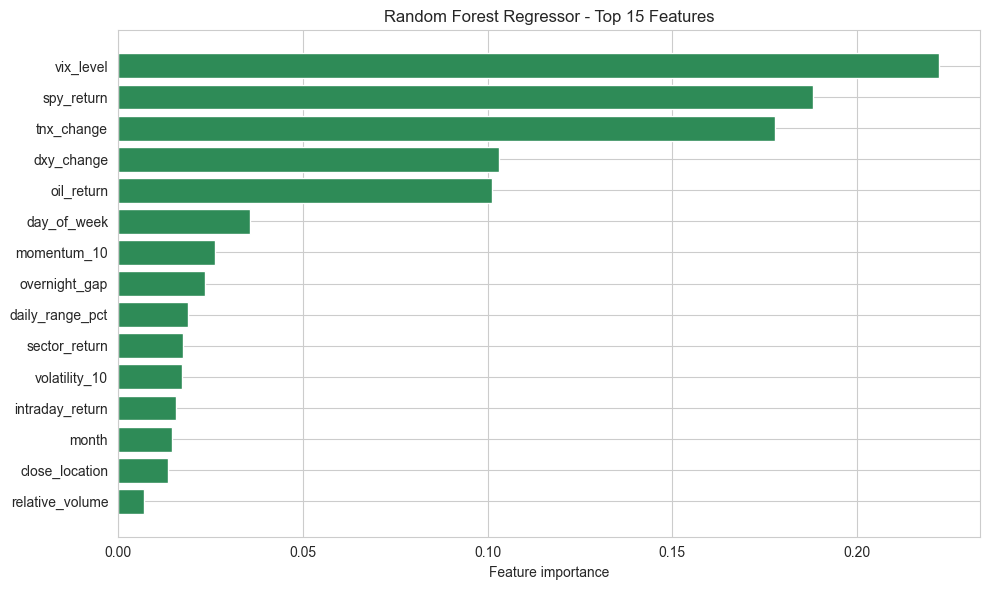

In [8]:
# Feature importance
rf_importance = pd.DataFrame({
    "feature": FEATURE_COLS,
    "importance": rf_best.feature_importances_,
}).sort_values("importance", ascending=False).reset_index(drop=True)

print("Top 10 features by RF importance:")
print(rf_importance.head(10).to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# Plot top 15 features horizontally
plt.figure(figsize=(10, 6))
top15 = rf_importance.head(15)
plt.barh(top15["feature"][::-1], top15["importance"][::-1], color="seagreen")
plt.xlabel("Feature importance")
plt.title("Random Forest Regressor - Top 15 Features")
plt.tight_layout()
plt.show()

## 7. Model 3 - LSTM Regressor

### Architecture

Same architecture as Phase 2 classifier, with two changes for regression:

1. **Final activation** is linear (no sigmoid) - the output can be any real number
2. **Loss function** is MAE (L1 loss) instead of BCE - we want to minimize absolute prediction error

```
Input (batch, 30 timesteps, 21 features)
  -> LSTM layer 1: 64 hidden units, returns all timesteps
  -> Dropout 0.2
  -> LSTM layer 2: 32 hidden units, returns only final hidden state
  -> Dropout 0.2
  -> Dense(32 -> 16) + ReLU
  -> Dense(16 -> 1)   [linear output, no activation]
```

### Sequence construction

Same as Phase 2: 30-day sliding windows per ticker. The label for each window is the regression target at the last day of the window.

### Training

- Loss: **MAE (L1Loss)** - matches our primary reporting metric
- Optimizer: Adam, learning rate 1e-3
- Batch size: 64
- Max epochs: 30, early stopping patience: 5 on validation loss

In [9]:
# Hyperparameters for the LSTM
SEQ_LEN      = 30       # Length of input window in days
HIDDEN_1     = 64       # Hidden size of first LSTM layer
HIDDEN_2     = 32       # Hidden size of second LSTM layer
DENSE_HIDDEN = 16       # Hidden size of dense layer before output
DROPOUT      = 0.2      # Dropout rate between layers
BATCH_SIZE   = 64
LR           = 1e-3
MAX_EPOCHS   = 30
PATIENCE     = 5


def make_sequences_per_ticker(df_slice, X_scaled, y, seq_len=SEQ_LEN):
    """
    Build sliding-window sequences per ticker.
    """
    df_reset = df_slice.reset_index()
    X_windows, y_windows = [], []
    for ticker, group in df_reset.groupby("ticker"):
        positions = group.index.values
        if len(positions) < seq_len:
            continue  # not enough rows for even one window
        for i in range(seq_len - 1, len(positions)):
            window_positions = positions[i - seq_len + 1 : i + 1]
            X_windows.append(X_scaled[window_positions])
            y_windows.append(y[positions[i]])
    return (
        np.array(X_windows, dtype=np.float32),
        np.array(y_windows, dtype=np.float32),
    )


class SequenceDataset(Dataset):
    """PyTorch Dataset wrapping numpy arrays of sequences and labels."""
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


class LSTMRegressor(nn.Module):
    """
    Stacked LSTM regressor: two LSTM layers (64 -> 32) followed by two Dense layers (16 -> 1).
    Output is a raw linear value - the predicted next-day return.
    """
    def __init__(self, n_features, hidden_1=HIDDEN_1, hidden_2=HIDDEN_2,
                 dense_hidden=DENSE_HIDDEN, dropout=DROPOUT):
        super().__init__()
        
        # LSTM 1: takes the raw 21-dim input, outputs a hidden_1-dim vector per timestep
        self.lstm1 = nn.LSTM(n_features, hidden_1, batch_first=True)
        self.dropout1 = nn.Dropout(dropout)
        
        # LSTM 2: takes LSTM 1's output and returns only the final hidden state
        self.lstm2 = nn.LSTM(hidden_1, hidden_2, batch_first=True)
        self.dropout2 = nn.Dropout(dropout)
        
        # Dense layers: hidden_2 -> dense_hidden -> 1 (linear output for regression)
        self.dense1 = nn.Linear(hidden_2, dense_hidden)
        self.relu = nn.ReLU()
        self.output = nn.Linear(dense_hidden, 1)
    
    def forward(self, x):
        
        # LSTM 1 returns all timesteps
        lstm1_out, _ = self.lstm1(x)
        lstm1_out = self.dropout1(lstm1_out)
        
        # LSTM 2 - take only the final hidden state
        _, (h_n, _) = self.lstm2(lstm1_out)
        final_hidden = h_n[-1]
        final_hidden = self.dropout2(final_hidden)
        
        # Dense layers - linear output (no activation applied here)
        h = self.relu(self.dense1(final_hidden))
        out = self.output(h).squeeze(-1)   # (batch,)
        return out


# Build sliding-window sequences for each split
print(f"Building {SEQ_LEN}-day sliding windows per ticker...")
X_train_seq, y_train_seq = make_sequences_per_ticker(df_full[train_mask], X_train, y_train)
X_val_seq,   y_val_seq   = make_sequences_per_ticker(df_full[val_mask],   X_val,   y_val)
X_test_seq,  y_test_seq  = make_sequences_per_ticker(df_full[test_mask],  X_test,  y_test)

print(f"  Train windows: {X_train_seq.shape}")
print(f"  Val windows:   {X_val_seq.shape}")
print(f"  Test windows:  {X_test_seq.shape}")

# Wrap in PyTorch DataLoaders
train_loader = DataLoader(SequenceDataset(X_train_seq, y_train_seq), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(SequenceDataset(X_val_seq,   y_val_seq),   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(SequenceDataset(X_test_seq,  y_test_seq),  batch_size=BATCH_SIZE, shuffle=False)

# Instantiate the model and move to GPU
lstm_reg = LSTMRegressor(n_features=len(FEATURE_COLS)).to(DEVICE)

total_params = sum(p.numel() for p in lstm_reg.parameters())
print(f"\nModel parameters: {total_params:,}")
print(lstm_reg)

Building 30-day sliding windows per ticker...
  Train windows: (41750, 30, 21)
  Val windows:   (7800, 30, 21)
  Test windows:  (7850, 30, 21)

Model parameters: 35,361
LSTMRegressor(
  (lstm1): LSTM(21, 64, batch_first=True)
  (dropout1): Dropout(p=0.2, inplace=False)
  (lstm2): LSTM(64, 32, batch_first=True)
  (dropout2): Dropout(p=0.2, inplace=False)
  (dense1): Linear(in_features=32, out_features=16, bias=True)
  (relu): ReLU()
  (output): Linear(in_features=16, out_features=1, bias=True)
)


In [10]:
# L1Loss = Mean Absolute Error loss 
criterion = nn.L1Loss()
optimizer = torch.optim.Adam(lstm_reg.parameters(), lr=LR)

# Early stopping state
best_val_loss = float("inf")
best_epoch = -1
best_state = None
patience_counter = 0
history = {"train_loss": [], "val_loss": []}

print(f"Training LSTM Regressor - up to {MAX_EPOCHS} epochs, patience {PATIENCE}")
print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Val Loss':>10} | Status")
print("-" * 60)

start = time.time()

for epoch in range(1, MAX_EPOCHS + 1):
    # Training pass
    lstm_reg.train()
    train_loss_sum = 0.0
    train_n = 0
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)
        
        preds = lstm_reg(X_batch)
        loss = criterion(preds, y_batch)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_loss_sum += loss.item() * X_batch.size(0)
        train_n += X_batch.size(0)
    train_loss = train_loss_sum / train_n
    
    # Validation pass - no gradients
    lstm_reg.eval()
    val_loss_sum = 0.0
    val_n = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            preds = lstm_reg(X_batch)
            loss = criterion(preds, y_batch)
            val_loss_sum += loss.item() * X_batch.size(0)
            val_n += X_batch.size(0)
    val_loss = val_loss_sum / val_n
    
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    
    # Early stopping check
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        best_state = {k: v.detach().cpu().clone() for k, v in lstm_reg.state_dict().items()}
        patience_counter = 0
        status = "v best"
    else:
        patience_counter += 1
        status = f"patience {patience_counter}/{PATIENCE}"
    
    print(f"{epoch:>5} | {train_loss:>10.6f} | {val_loss:>10.6f} | {status}")
    
    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}. Best val loss {best_val_loss:.6f} at epoch {best_epoch}.")
        break

lstm_time = time.time() - start
print(f"\nTraining complete in {lstm_time:.1f}s")

# Restore weights from the best epoch
lstm_reg.load_state_dict(best_state)
print(f"Restored weights from epoch {best_epoch}.")

Training LSTM Regressor - up to 30 epochs, patience 5
Epoch | Train Loss |   Val Loss | Status
------------------------------------------------------------
    1 |   0.014785 |   0.014205 | v best
    2 |   0.012798 |   0.014074 | v best
    3 |   0.012709 |   0.014243 | patience 1/5
    4 |   0.012548 |   0.014400 | patience 2/5
    5 |   0.012374 |   0.014551 | patience 3/5
    6 |   0.012124 |   0.015316 | patience 4/5
    7 |   0.011891 |   0.016214 | patience 5/5

Early stopping at epoch 7. Best val loss 0.014074 at epoch 2.

Training complete in 15.9s
Restored weights from epoch 2.


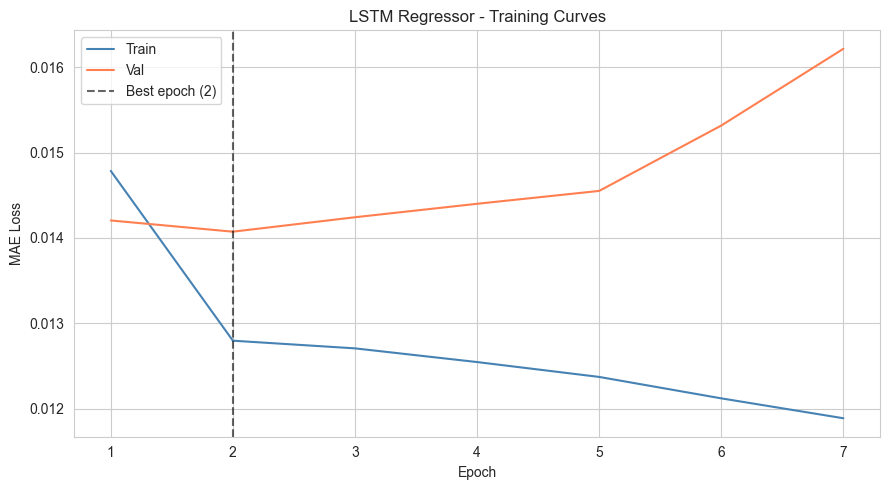

In [11]:
# Plot training curves to diagnose overfitting / early stopping behaviour
epochs_ran = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(9, 5))
plt.plot(epochs_ran, history["train_loss"], label="Train", color="steelblue")
plt.plot(epochs_ran, history["val_loss"],   label="Val",   color="coral")
plt.axvline(best_epoch, color="black", linestyle="--", alpha=0.6, label=f"Best epoch ({best_epoch})")
plt.xlabel("Epoch")
plt.ylabel("MAE Loss")
plt.title("LSTM Regressor - Training Curves")
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
# Evaluate the LSTM on the test set
lstm_reg.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        preds = lstm_reg(X_batch)
        all_preds.append(preds.cpu().numpy())
        all_targets.append(y_batch.numpy())

# Concatenate batches
all_preds = np.concatenate(all_preds)
all_targets = np.concatenate(all_targets)

# Compute regression metrics
lstm_mae  = mean_absolute_error(all_targets, all_preds)
lstm_rmse = np.sqrt(mean_squared_error(all_targets, all_preds))
lstm_r2   = r2_score(all_targets, all_preds)

print(f"LSTM Regressor - Test Performance\n")
print(f"MAE:       {lstm_mae:.6f}")
print(f"RMSE:      {lstm_rmse:.6f}")
print(f"R-squared: {lstm_r2:+.4f}")
print(f"\nPrediction distribution on test:")
print(f"  Mean:      {all_preds.mean():+.5f}")
print(f"  Std:       {all_preds.std():.5f}")
print(f"  Std ratio: {all_preds.std() / all_targets.std():.4f}  (predictions / actuals)")

LSTM Regressor - Test Performance

MAE:       0.013017
RMSE:      0.018639
R-squared: +0.0019

Prediction distribution on test:
  Mean:      +0.00053
  Std:       0.00174
  Std ratio: 0.0932  (predictions / actuals)


## 8. Model Comparison

All three regressors evaluated on the same test set. The comparison table shows test metrics side by side, and we include a scatter plot of predicted vs actual returns for each model - a useful visual check of how well each model tracks the true values.

In [13]:
# Build the side-by-side comparison table
comparison = pd.DataFrame([
    {"Model": "Linear Regression", "MAE": linreg_mae, "RMSE": linreg_rmse, "R-squared": linreg_r2},
    {"Model": "Random Forest",     "MAE": rf_mae,     "RMSE": rf_rmse,     "R-squared": rf_r2},
    {"Model": "LSTM",              "MAE": lstm_mae,   "RMSE": lstm_rmse,   "R-squared": lstm_r2},
])

print("REGRESSION MODEL COMPARISON - Test Set\n")
print(comparison.to_string(index=False, float_format=lambda x: f"{x:.6f}"))

# Identify best model by lowest MAE
best_idx = comparison["MAE"].idxmin()
print(f"\nBest model by MAE: {comparison.loc[best_idx, 'Model']} ({comparison.loc[best_idx, 'MAE']:.6f})")

REGRESSION MODEL COMPARISON - Test Set

            Model      MAE     RMSE  R-squared
Linear Regression 0.012728 0.018346  -0.001935
    Random Forest 0.012789 0.018404  -0.008233
             LSTM 0.013017 0.018639   0.001869

Best model by MAE: Linear Regression (0.012728)


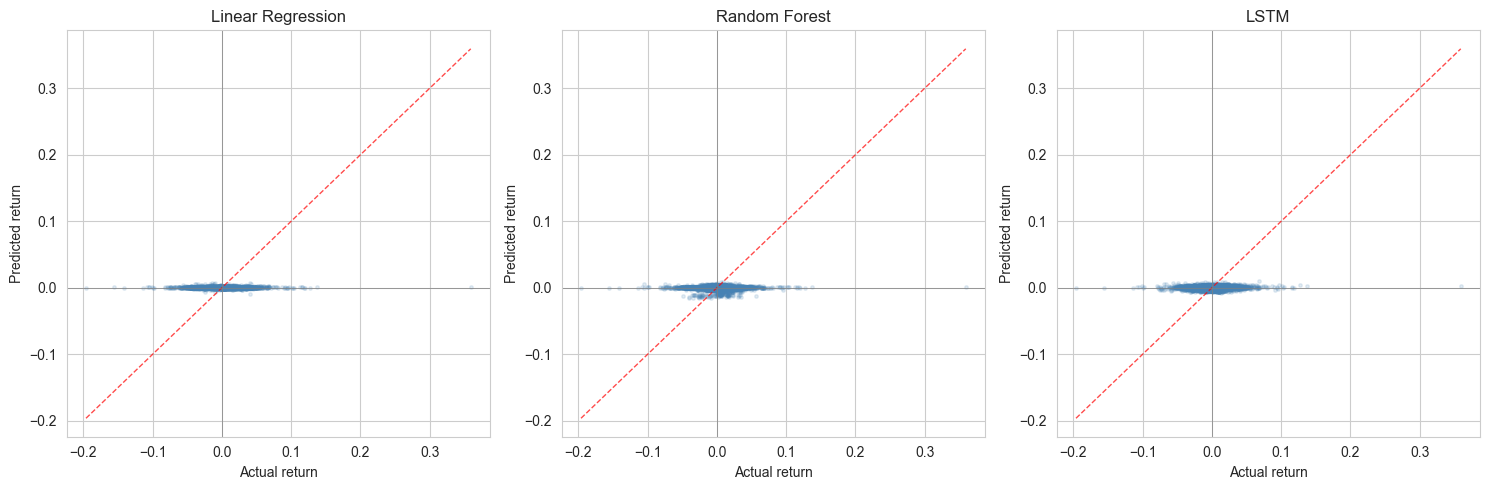

In [14]:
# Scatter plot: predicted vs actual returns for each model.
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
preds_list = [
    ("Linear Regression", linreg_preds, y_test),
    ("Random Forest",     rf_preds,     y_test),
    ("LSTM",              all_preds,    all_targets),
]

for ax, (name, preds, actuals) in zip(axes, preds_list):
    ax.scatter(actuals, preds, alpha=0.15, s=6, color="steelblue")
    
    # Diagonal reference line (y = x) representing perfect predictions
    lo = min(actuals.min(), preds.min())
    hi = max(actuals.max(), preds.max())
    ax.plot([lo, hi], [lo, hi], color="red", linestyle="--", linewidth=1, alpha=0.7)
    
    ax.set_title(f"{name}")
    ax.set_xlabel("Actual return")
    ax.set_ylabel("Predicted return")
    ax.axhline(0, color="gray", linewidth=0.5)
    ax.axvline(0, color="gray", linewidth=0.5)

plt.tight_layout()
plt.show()

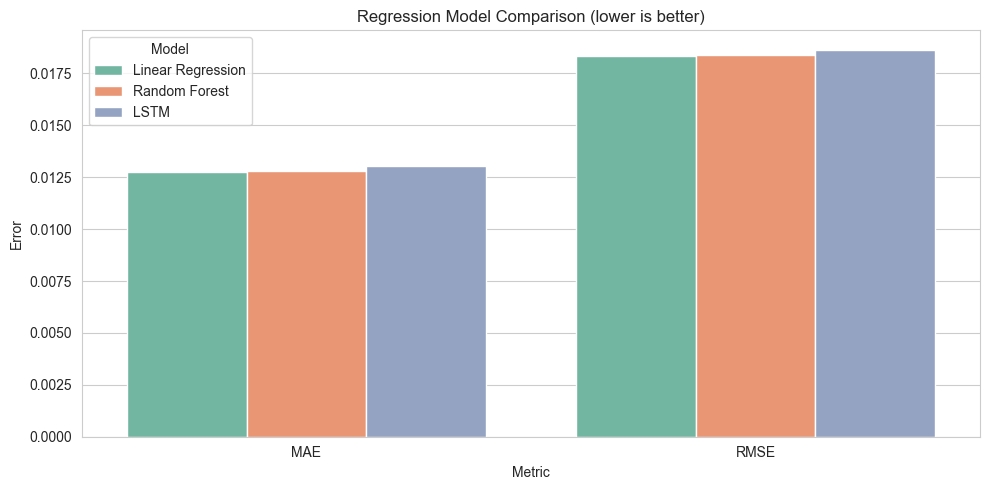

In [15]:
# Bar chart of MAE and RMSE across models.
metrics_long = comparison[["Model", "MAE", "RMSE"]].melt(
    id_vars="Model", var_name="Metric", value_name="Value"
)

plt.figure(figsize=(10, 5))
sns.barplot(data=metrics_long, x="Metric", y="Value", hue="Model", palette="Set2")
plt.title("Regression Model Comparison (lower is better)")
plt.ylabel("Error")
plt.legend(title="Model", loc="upper left")
plt.tight_layout()
plt.show()

## 9. Save Models

Save all three trained regressors plus the fitted `StandardScaler` to the `models/` directory. These files will be consumed by our Flask app for inference.

- Linear Regression and Random Forest: pickled via `pickle`
- LSTM: saved as full model via `torch.save` (includes architecture + weights)
- Scaler: pickled so preprocessing matches at inference time

In [16]:
# Create the models directory if it doesn't exist
models_dir = Path("../models")
models_dir.mkdir(parents=True, exist_ok=True)

# Save Linear Regression
with open(models_dir / "linear_regression.pkl", "wb") as f:
    pickle.dump(linreg, f)

# Save Random Forest (the best estimator from the grid search)
with open(models_dir / "random_forest_regressor.pkl", "wb") as f:
    pickle.dump(rf_best, f)

# Save LSTM as a whole model - simpler for Flask to load than a state-dict approach
torch.save(lstm_reg, models_dir / "lstm_regressor.pt")

# Save the scaler - critical to preprocess new data identically at inference time
with open(models_dir / "scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

# List what was saved
print("Saved models:")
for fname in ["linear_regression.pkl", "random_forest_regressor.pkl", "lstm_regressor.pt", "scaler.pkl"]:
    f = models_dir / fname
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name:<30} ({size_kb:>9.1f} KB)")

Saved models:
  linear_regression.pkl          (      0.6 KB)
  random_forest_regressor.pkl    (    821.8 KB)
  lstm_regressor.pt              (    144.1 KB)
  scaler.pkl                     (      0.9 KB)
